# Stockholm Museum Storytelling

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt

BLUE = "#1E88E5"    
GREEN = "#43A047"     
RED = "#E53935"     
ORANGE = "#FB8C00"    
PURPLE = "#8E24AA"    
TEAL = "#00897B"       
YELLOW = "#FDD835"     
PINK = "#D81B60"      
GRAY_1= "#EAEAEA"  
GRAY_2 = "#B0BEC5"   
GRAY_3 = "#37474F" 
BAKGRUND = "#FFFFFF"
KORALL = "#FF6666"  



In [2]:
df= pd.read_csv("api/data/stockholm_museums_complete.csv")

df.head()

,event_id,name,url,venue_name,venue_address,venue_city,venue_lat,venue_lon,rating,num_reviews,...,year,month_name,is_free,popularity_score,popularity_index,adult_price_sek,child_price_sek,free_age_range,student_price_sek,senior_price_sek
0,ChIJrymDbVSdX0YRQTLBtPGa8M8,Vasamuseet,https://www.vasamuseet.se/,Vasamuseet,"Galärvarvsvägen 14, 115 21 Stockholm, Sverige",Stockholm,59.328023,18.091396,4.8,66926,...,2026,All Year,False,1241.8,100.0,240.0,0.0,0–18,NaN,NaN
1,ChIJN5Ta_qqCX0YRMYVG1s-2NSw,Skansen,https://www.skansen.se/,Skansen,"Djurgårdsslätten 49-51, 115 21 Stockholm, Sverige",Stockholm,59.326323,18.105858,4.5,34496,...,2026,All Year,False,835.8,62.9,329.0,120.0,0–15,279.0,279.0
2,ChIJBf9B06qCX0YRR46XNXjwFUo,ABBA The Museum,https://www.abbathemuseum.com/,ABBA The Museum,"Djurgårdsvägen 68, 115 21 Stockholm, Sverige",Stockholm,59.325091,18.096781,4.5,20093,...,2026,All Year,False,637.9,44.8,329.0,120.0,0–6,279.0,279.0
3,ChIJhaN0M_l3X0YRpOq8uRb_RcA,Fotografiska Stockholm,https://stockholm.fotografiska.com/,Fotografiska Stockholm,"Stadsgårdshamnen 22, 116 45 Stockholm, Sverige",Stockholm,59.317962,18.084827,4.4,19504,...,2026,All Year,False,614.5,42.6,NaN,NaN,NaN,NaN,NaN
4,ChIJxagZg1OdX0YRGKnPhRyci9c,Nordiska museet,https://www.nordiskamuseet.se/,Nordiska museet,"Djurgårdsvägen 6-16, 115 93 Stockholm, Sverige",Stockholm,59.329008,18.094268,4.3,11098,...,2026,All Year,False,453.0,27.9,160.0,0.0,3–18,130.0,130.0


# Top Museums by Popularity, “Where are people actually going?”

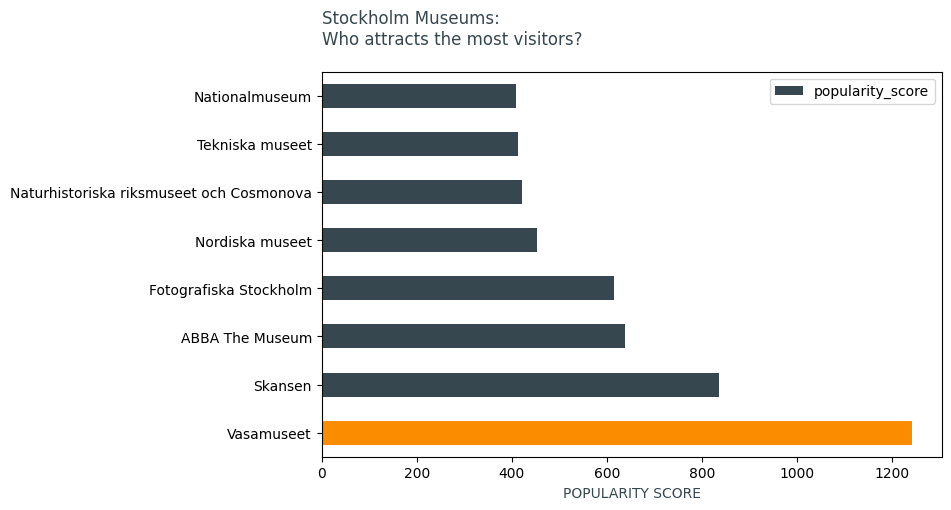

In [4]:
df_pop = df.sort_values("popularity_score", ascending=True).tail(8)

colors = [GRAY_3] * len(df_pop)
colors[-1] = ORANGE  # highlight leader

ax = df_pop.plot(
    kind="barh",
    x="name",
    y="popularity_score",
    figsize=(8,5),
    color=colors
)

ax.set_title(
    "Stockholm Museums:\nWho attracts the most visitors?",
    loc="left", color=GRAY_3, pad=20
)

ax.set_xlabel("POPULARITY SCORE", color=GRAY_3)
ax.set_ylabel("")

ax.invert_yaxis()

# Rating vs Popularity (THE BEST INSIGHT), “Are the most popular museums also the best rated?.”

Text(4.8, 1241.8, 'Vasamuseet')

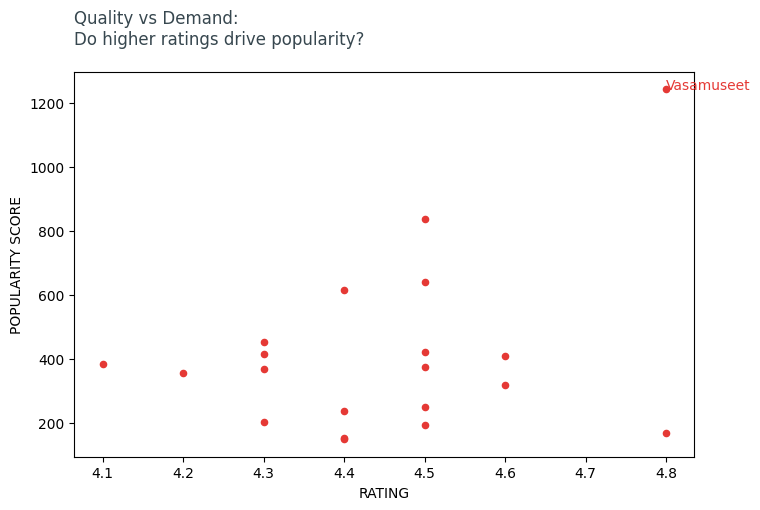

In [19]:
ax = df.plot(
    kind="scatter",
    x="rating",
    y="popularity_score",
    figsize=(8,5),
    color= RED
)

ax.set_title(
    "Quality vs Demand:\nDo higher ratings drive popularity?",
    loc="left", color=GRAY_3, pad=20
)

ax.set_xlabel("RATING")
ax.set_ylabel("POPULARITY SCORE")

# highlight top performer
top = df.loc[df["popularity_score"].idxmax()]
ax.annotate(
    top["name"],
    (top["rating"], top["popularity_score"]),
    color=RED
)

# KPI: Free vs Paid Museums, “Does free access drive popularity?”

Text(0, 0.5, 'AVG POPULARITY')

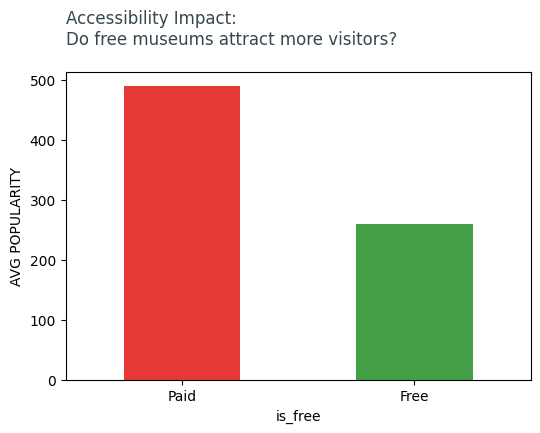

In [13]:
df_free = df.groupby("is_free")["popularity_score"].mean()

colors = [RED, GREEN]  # False vs True

ax = df_free.plot(kind="bar", figsize=(6,4), color=colors)

ax.set_title(
    "Accessibility Impact:\nDo free museums attract more visitors?",
    loc="left", color=GRAY_3, pad=20
)

ax.set_xticklabels(["Paid", "Free"], rotation=0)
ax.set_ylabel("AVG POPULARITY")

# Price vs Popularity, “Does pricing impact demand?”

Text(0, 0.5, 'POPULARITY SCORE')

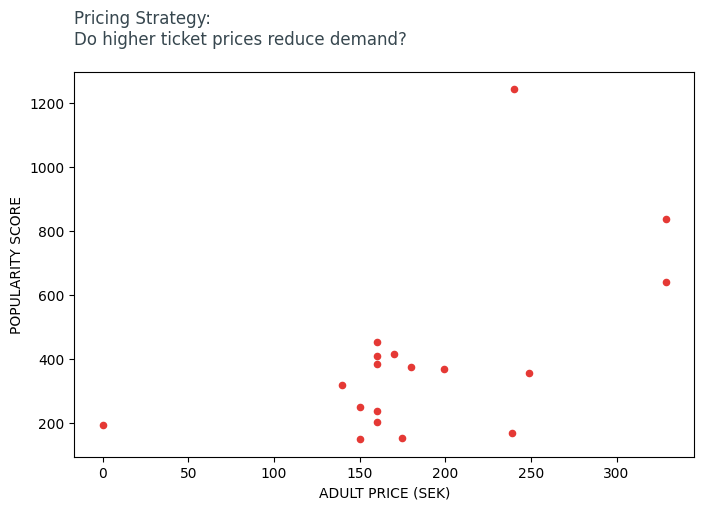

In [16]:
df_price = df.dropna(subset=["adult_price_sek"])

ax = df_price.plot(
    kind="scatter",
    x="adult_price_sek",
    y="popularity_score",
    figsize=(8,5),
    color=RED
)

ax.set_title(
    "Pricing Strategy:\nDo higher ticket prices reduce demand?",
    loc="left", color=GRAY_3, pad=20
)

ax.set_xlabel("ADULT PRICE (SEK)")
ax.set_ylabel("POPULARITY SCORE")